# SOM — Mapa de Perfiles de Futbolistas

| Campo | Valor |
|:------|:------|
| **Autor** | Borja Mora Mendez |
| **Contacto** | borja.mora.mendez@gmail.com |
| **LinkedIn** | [linkedin.com/in/borjamoramendez](https://linkedin.com/in/borjamoramendez) |
| **Categoria** | Machine Learning > Redes Neuronales > SOM (No supervisado) |
| **Dataset** | jugadores_futbol.xlsx (800 jugadores, 6 atributos + posicion) |
| **Ultima actualizacion** | Julio 2026 |

## 1. Contexto de negocio

El departamento de scouting de un club de futbol analiza 800 jugadores
para identificar perfiles tacticos y detectar jugadores infravalorados.
Las herramientas actuales (rankings 1D, filtros manuales) no capturan
la combinacion multidimensional de habilidades.

El SOM proyecta las 6 dimensiones de rendimiento en un mapa 2D donde
jugadores con perfiles similares quedan cerca, revelando:
- Arquetipos tacticos naturales (no los que asume el entrenador).
- Jugadores versatiles que se situan entre zonas.
- Perfiles anomalos dignos de scouting detallado.

Pregunta analitica: **como se distribuyen los perfiles tacticos
en el espacio de habilidades, y coinciden con las posiciones reales?**

## 2. Objetivo y justificacion del modelo

Usamos SOM para descubrir la topologia del talento futbolistico.
La posicion real (Defensa/Centrocampista/Delantero) sirve como etiqueta
de validacion, no como input del modelo (aprendizaje no supervisado).

| Modelo | Ventaja | Limitacion |
|:-------|:--------|:-----------|
| SOM | Preserva topologia, descubre arquetipos | No asigna clusters |
| K-Means | Clusters claros | No revela vecindades |
| PCA | Reduccion lineal rapida | No captura no-linealidades |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


## 4. Carga y exploracion inicial

### Diccionario de variables

| Variable | Tipo | Descripcion |
|:---------|:-----|:------------|
| Velocidad | float | Capacidad de sprint (0-100) |
| Tiro | float | Precision y potencia de disparo |
| Regate | float | Habilidad de regate |
| Pase | float | Precision de pase |
| Defensa | float | Capacidad defensiva |
| Fisico | float | Fuerza y resistencia |
| Posicion_Real | str | Posicion asignada por el club |

In [2]:
df = pd.read_excel('jugadores_futbol.xlsx')
# Normalizar nombre de columna
df.columns = [c.replace('í', 'i') for c in df.columns]
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
print(f'\nDistribucion de posiciones:')
print(df['Posicion_Real'].value_counts())
print(f'\nEstadisticas por posicion:')
atributos = ['Velocidad', 'Tiro', 'Regate', 'Pase', 'Defensa', 'Fisico']
print(df.groupby('Posicion_Real')[atributos].mean().round(1))

Shape: (800, 7)
Columnas: ['Velocidad', 'Tiro', 'Regate', 'Pase', 'Defensa', 'Fisico', 'Posicion_Real']

Distribucion de posiciones:
Posicion_Real
Defensa           300
Centrocampista    300
Delantero         200
Name: count, dtype: int64

Estadisticas por posicion:
                Velocidad  Tiro  Regate  Pase  Defensa  Fisico
Posicion_Real                                                 
Centrocampista       70.0  65.3    74.9  84.3     59.9    70.8
Defensa              66.1  39.8    50.0  65.6     84.7    80.7
Delantero            84.4  79.6    85.1  69.0     34.7    65.2


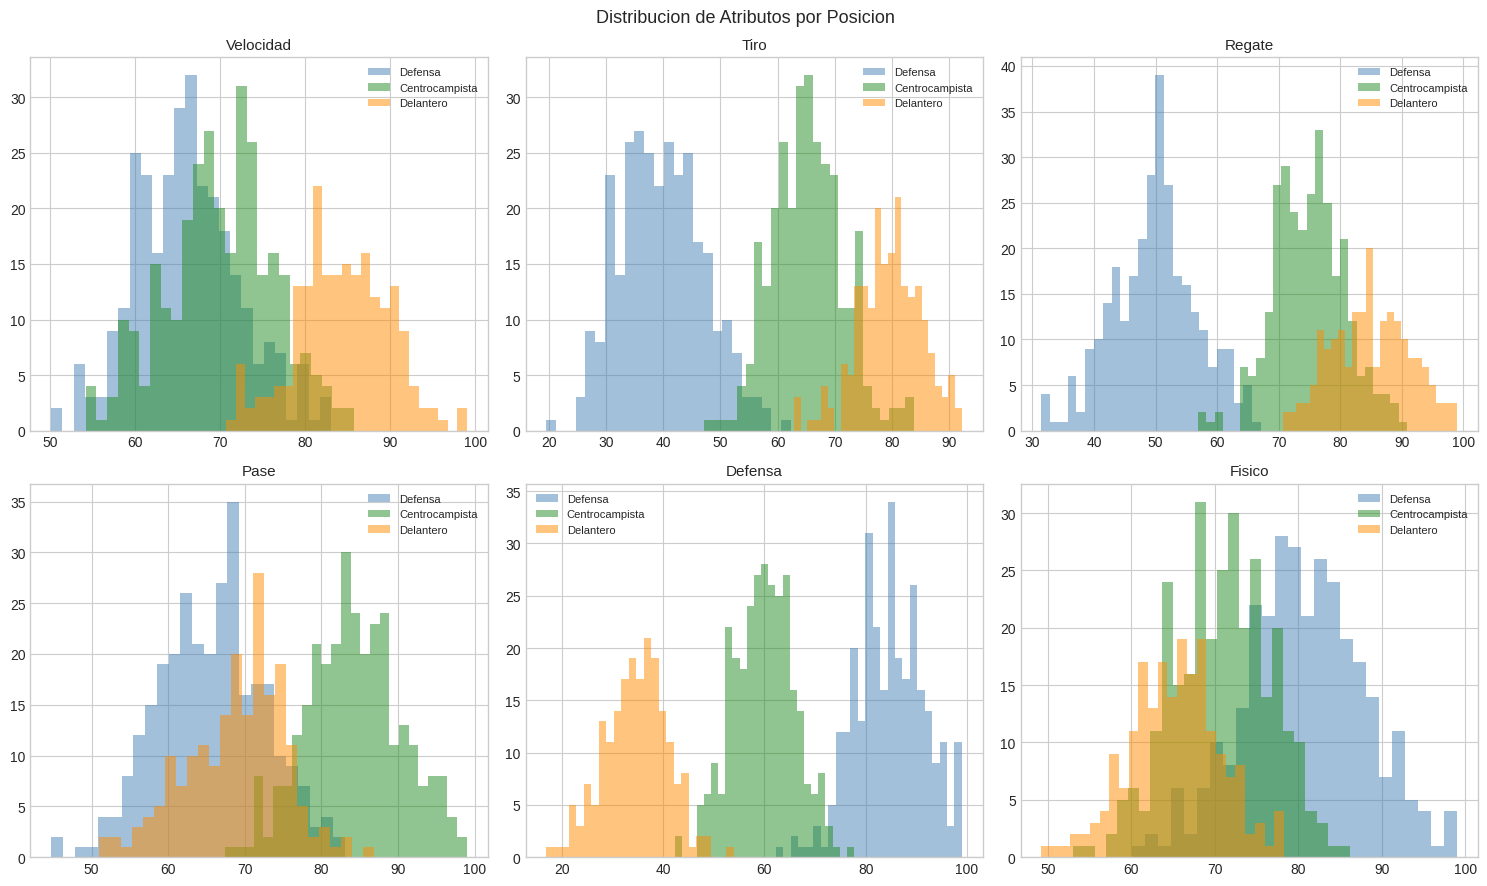

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
atributos = ['Velocidad', 'Tiro', 'Regate', 'Pase', 'Defensa', 'Fisico']
for ax, attr in zip(axes.flat, atributos):
    for pos, color in [('Defensa', 'steelblue'), ('Centrocampista', 'forestgreen'), ('Delantero', 'darkorange')]:
        subset = df[df['Posicion_Real'] == pos]
        ax.hist(subset[attr], bins=25, alpha=0.5, label=pos, color=color)
    ax.set_title(attr, fontsize=11)
    ax.legend(fontsize=8)
plt.suptitle('Distribucion de Atributos por Posicion', fontsize=13)
plt.tight_layout()
plt.show()

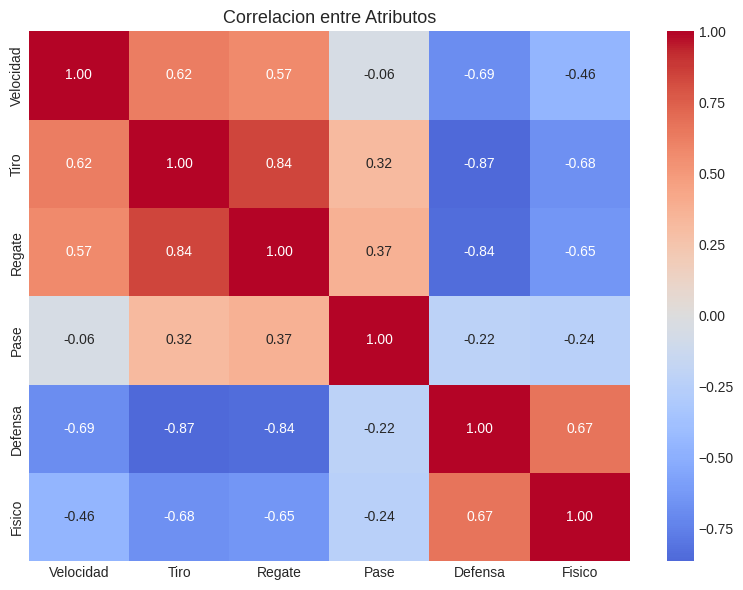

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[atributos].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlacion entre Atributos', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Preparacion de datos

In [5]:
X = df[atributos].values
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
print(f'Shape escalado: {X_sc.shape}')

Shape escalado: (800, 6)


## 6. Modelo principal: Self-Organizing Map

Rejilla 12x12 (144 neuronas) para 800 jugadores. Sigma=2.0 para
capturar relaciones de vecindad amplias.

In [6]:
np.random.seed(42)
som = MiniSom(
    x=12, y=12,
    input_len=X_sc.shape[1],
    sigma=2.0,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42
)
som.random_weights_init(X_sc)
som.train_random(X_sc, num_iteration=5000)
print(f'Entrenamiento completado: 5000 iteraciones')
print(f'Error de cuantizacion: {som.quantization_error(X_sc):.4f}')

Entrenamiento completado: 5000 iteraciones
Error de cuantizacion: 0.6789


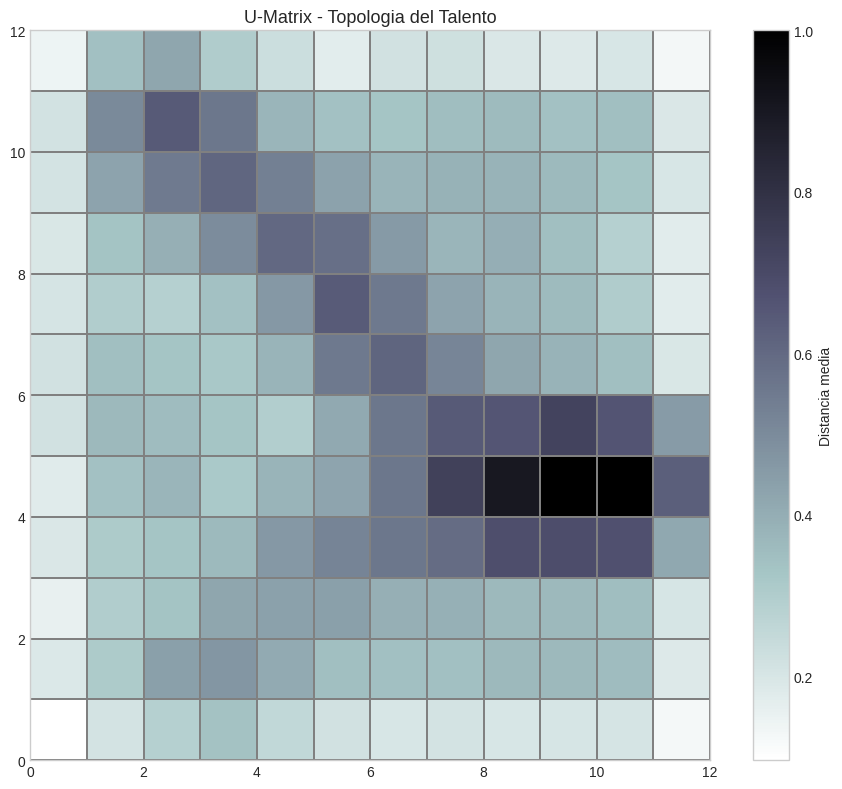

In [7]:
fig, ax = plt.subplots(figsize=(9, 8))
umatrix = som.distance_map()
im = ax.pcolormesh(umatrix.T, cmap='bone_r', edgecolors='gray', linewidth=0.3)
ax.set_title('U-Matrix - Topologia del Talento', fontsize=13)
plt.colorbar(im, ax=ax, label='Distancia media')
plt.tight_layout()
plt.show()

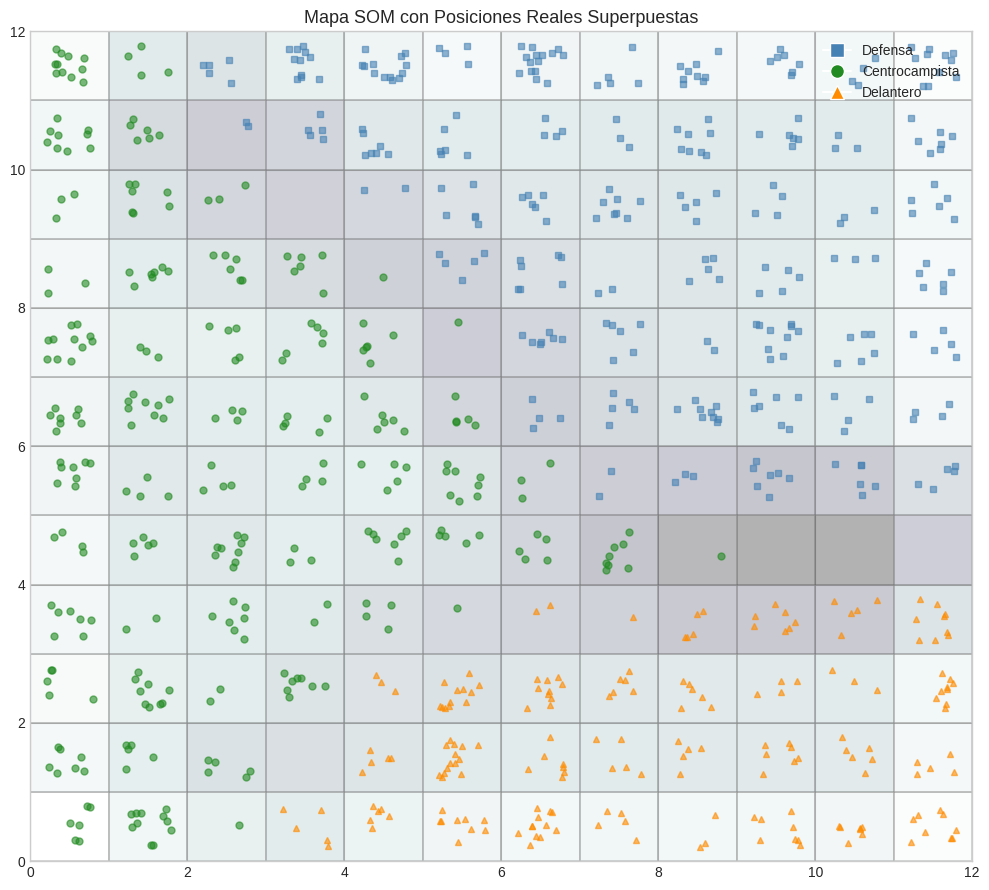

In [8]:
colores_pos = {'Defensa': 'steelblue', 'Centrocampista': 'forestgreen', 'Delantero': 'darkorange'}
marcadores_pos = {'Defensa': 's', 'Centrocampista': 'o', 'Delantero': '^'}

fig, ax = plt.subplots(figsize=(10, 9))
ax.pcolormesh(umatrix.T, cmap='bone_r', alpha=0.3, edgecolors='gray', linewidth=0.3)

for i, x in enumerate(X_sc):
    w = som.winner(x)
    pos = df.iloc[i]['Posicion_Real']
    ax.plot(w[0] + 0.5 + np.random.uniform(-0.3, 0.3),
            w[1] + 0.5 + np.random.uniform(-0.3, 0.3),
            marcadores_pos[pos], color=colores_pos[pos],
            markersize=5, alpha=0.6)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker=m, color='w', markerfacecolor=c,
                          markersize=10, label=p)
                   for p, c, m in zip(colores_pos.keys(), colores_pos.values(), marcadores_pos.values())]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
ax.set_title('Mapa SOM con Posiciones Reales Superpuestas', fontsize=13)
plt.tight_layout()
plt.show()

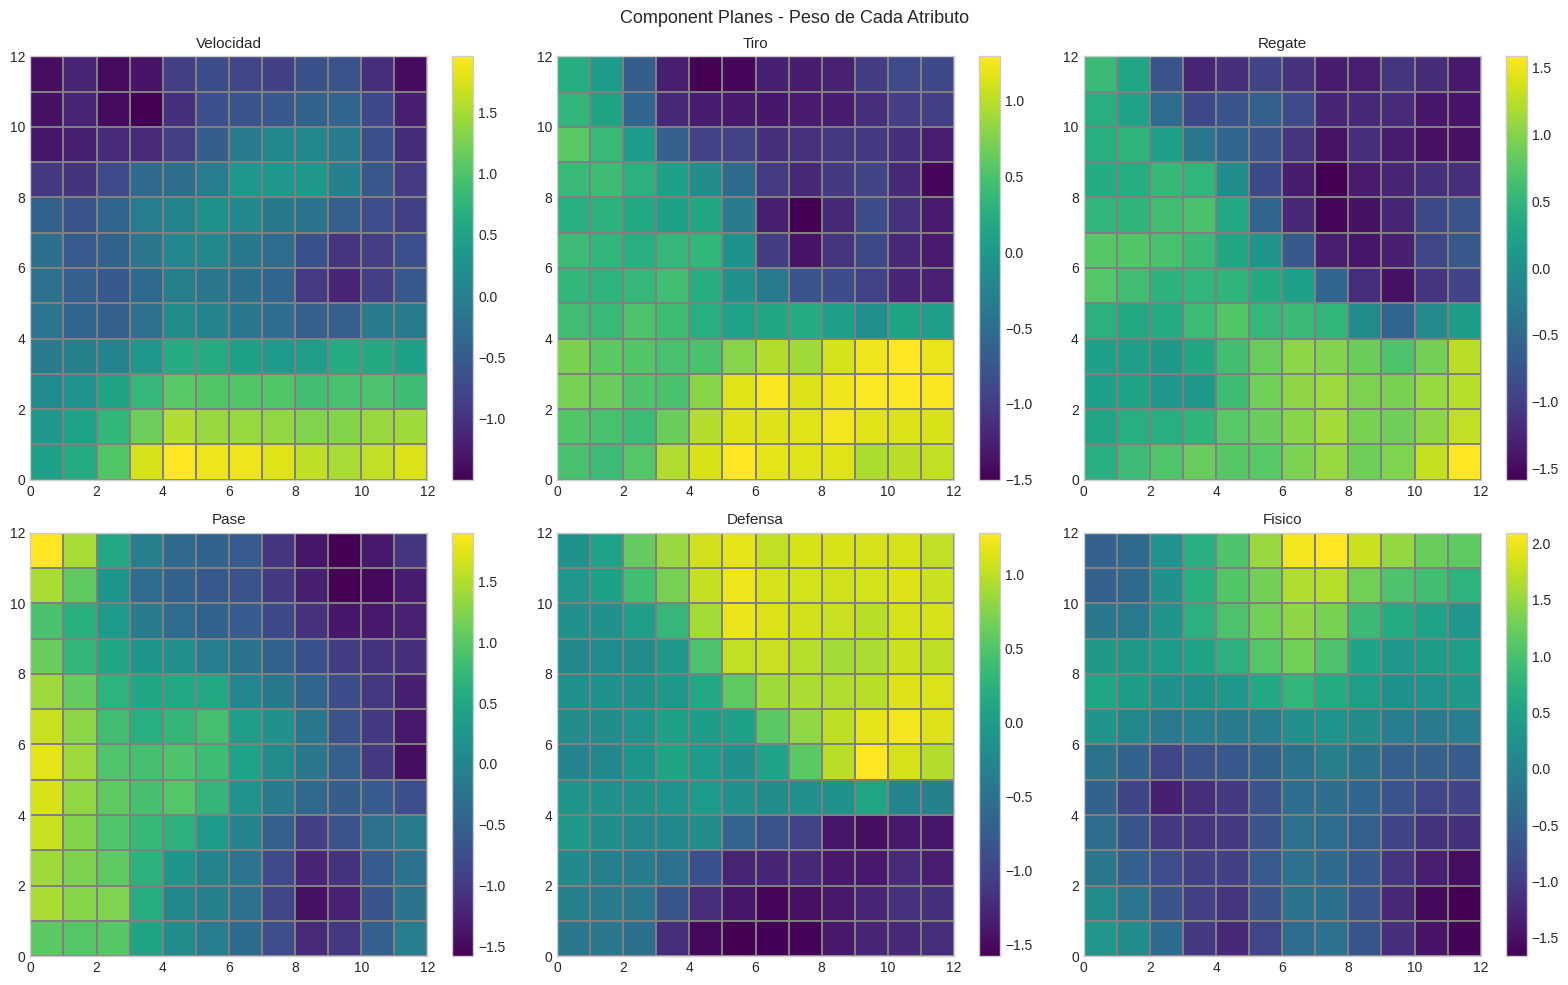

In [9]:
weights = som.get_weights()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, (ax, attr) in enumerate(zip(axes.flat, atributos)):
    im = ax.pcolormesh(weights[:, :, i].T, cmap='viridis',
                       edgecolors='gray', linewidth=0.2)
    ax.set_title(f'{attr}', fontsize=11)
    plt.colorbar(im, ax=ax)
plt.suptitle('Component Planes - Peso de Cada Atributo', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Modelo alternativo: PCA para validacion

Proyectamos con PCA 2D para comparar la separacion de posiciones
con la del SOM.

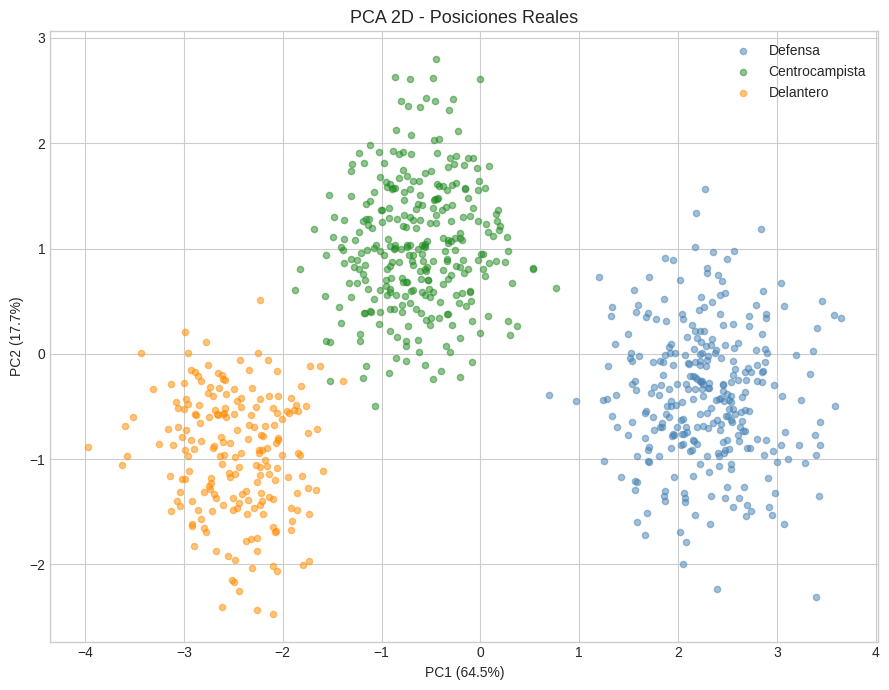

Varianza explicada total: 82.2%


In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)

fig, ax = plt.subplots(figsize=(9, 7))
for pos, color in colores_pos.items():
    mask = df['Posicion_Real'] == pos
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=pos, alpha=0.5, s=20)
ax.set_title('PCA 2D - Posiciones Reales', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Varianza explicada total: {pca.explained_variance_ratio_.sum():.1%}')

## 8. Analisis de jugadores versatiles

In [11]:
versatilidad = []
for i, x in enumerate(X_sc):
    w = som.winner(x)
    versatilidad.append(umatrix[w[0], w[1]])
df['Versatilidad_SOM'] = versatilidad

print('Top 10 jugadores mas versatiles (frontera entre arquetipos):')
top = df.nlargest(10, 'Versatilidad_SOM')[['Posicion_Real', 'Velocidad', 'Tiro',
                                            'Regate', 'Pase', 'Defensa', 'Fisico',
                                            'Versatilidad_SOM']]
print(top.round(1).to_string())

Top 10 jugadores mas versatiles (frontera entre arquetipos):
      Posicion_Real  Velocidad  Tiro  Regate  Pase  Defensa  Fisico  Versatilidad_SOM
527  Centrocampista       67.2  60.8    68.1  74.5     57.7    70.9               0.9
328  Centrocampista       68.8  71.8    78.6  67.4     63.9    71.2               0.7
419  Centrocampista       69.2  67.0    75.5  71.7     58.6    64.9               0.7
432  Centrocampista       69.7  65.3    80.1  71.5     56.4    71.3               0.7
507  Centrocampista       66.5  66.3    79.3  72.7     67.0    68.0               0.7
523  Centrocampista       72.8  63.4    80.1  72.2     59.4    66.4               0.7
548  Centrocampista       66.2  63.3    83.5  70.1     67.7    72.0               0.7
559  Centrocampista       66.4  64.0    75.5  72.2     62.7    64.1               0.7
567  Centrocampista       71.2  64.4    77.6  69.8     64.1    70.8               0.7
36          Defensa       59.6  38.3    46.6  65.6     99.0    66.9            

## 10. Tabla comparativa

| Metodo | Topologia | Descubre arquetipos | Validacion visual |
|:-------|:----------|:--------------------|:------------------|
| SOM (12x12) | Si | Si (component planes) | Excelente |
| PCA 2D | No (lineal) | Parcial | Buena |

El SOM revela la estructura no-lineal del espacio de habilidades
mejor que PCA, mostrando zonas de transicion entre posiciones.

## 11. Insights y recomendaciones accionables

### Hallazgo clave
El mapa SOM muestra 3 zonas claras (defensas, centrocampistas, delanteros)
con zonas de transicion donde se situan jugadores polivalentes.
Los component planes revelan que Defensa y Fisico dominan una zona
mientras que Tiro y Regate dominan la opuesta.

### Recomendaciones

**1. Scouting basado en vecindad SOM (impacto: alto, esfuerzo: bajo)**
Buscar jugadores cercanos a la neurona de un jugador estrella de referencia.
Si quieres reemplazar a un centrocampista creativo, explorar las neuronas
vecinas en el mapa.

**2. Detectar jugadores infravalorados (impacto: alto, esfuerzo: medio)**
Jugadores versatiles (alta distancia U-Matrix) que estan en la frontera
entre posiciones pueden estar infrautilizados en su posicion actual.

**3. Dashboard interactivo de scouting (impacto: medio, esfuerzo: medio)**
Implementar el mapa SOM en Plotly con hover que muestre el perfil
completo del jugador. Util para directores deportivos.